## Deliverable 4: Nevada Housing Survey Analysis
The goal of this analysis is to evaluate attitudes toward housing affordability among Nevada registered voters using statewide survey data. This analysis uses raw statewide survey data on housing affordability in Nevada. The target universe is Nevada registered voters. The workflow follows standard Exploratory Data Analysis principles:
1. Understand the data and survey universe
2. Inspect missingness, variable types, and response distributions
3. Produce key toplines
4. Produce strategically useful crosstabs
5. Flag methodological issues before treating results as representative
6. Write a brief client-facing memo

### Files Used:
1. Raw data - `nv_housing_raw.csv`
2. Codebook (for metadata and understanding variables)- `nv_housing_codebook.csv` 

In [39]:
# load packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
nv_data = pd.read_csv("data/nv_housing_raw.csv")
nv_data_codebook = pd.read_csv("data/nv_housing_codebook.csv")

print("Raw survey data shape:", nv_data.shape)
print("Codebook shape:", nv_data_codebook.shape)

display(nv_data.head())
display(nv_data_codebook.head(30))

Raw survey data shape: (1000, 24)
Codebook shape: (24, 4)


,response_id,mode,status,attention_check,duration_seconds,region,county,age,gender,race_ethnicity,...,homeownership,children_home,housing_cost_seriousness,allow_more_housing,rent_increase_limit,affordable_housing_tax_credits,development_traffic_concern,corporate_buyer_restrictions,public_land_housing,housing_priority_tradeoff
0,NVH00001,online,terminated,Passed,565,Clark,Clark,76,Female,White non-Hispanic,...,Rent,No,Somewhat serious,Somewhat support,Somewhat support,Somewhat oppose,Not too concerned,Somewhat support,Not sure,Protect existing neighborhoods even if fewer h...
1,NVH00002,online,complete,Passed,935,Clark,Clark,24,Male,White non-Hispanic,...,Rent,No,Very serious,Not sure,Somewhat oppose,Somewhat support,Very concerned,Not sure,Somewhat oppose,Build more homes even if neighborhoods change
2,NVH00003,online,complete,Failed,1000,Clark,Clark,75,Male,White non-Hispanic,...,Rent,No,Very serious,Strongly oppose,Strongly support,Somewhat oppose,Somewhat concerned,Somewhat oppose,Strongly oppose,Build more homes even if neighborhoods change
3,NVH00004,online,complete,Failed,1391,Clark,Clark,46,Female,White non-Hispanic,...,Rent,No,Very serious,Somewhat support,Not sure,Strongly oppose,Not too concerned,Somewhat oppose,Strongly support,Protect existing neighborhoods even if fewer h...
4,NVH00005,sms,complete,Passed,171,Clark,Clark,34,Male,White non-Hispanic,...,Rent,Yes,Very serious,Strongly support,Somewhat support,Not sure,Somewhat concerned,Not sure,Strongly oppose,Build more homes even if neighborhoods change


,column,description,valid_values,question_text
0,response_id,Unique response ID,NaN,NaN
1,mode,Interview mode,online; sms,NaN
2,status,Interview disposition,complete; partial; terminated,NaN
3,attention_check,Attention check result,Passed; Failed,NaN
4,duration_seconds,Survey duration in seconds,Integer,NaN
5,region,Nevada region,Clark; Washoe; Rural Nevada,NaN
6,county,County,County name,NaN
7,age,Age,18-84,NaN
8,gender,Gender,Male; Female,NaN
9,race_ethnicity,Race/ethnicity,White non-Hispanic; Hispanic/Latino; Black; As...,NaN


In [ ]:
#Step 2: Basic structure check for the raw data
print("\nColumn types:")
display(nv_data.dtypes.value_counts())

print("\nMissingness summary:")
# Missingness summary
missing = (
    nv_data.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
)

missing.columns = ["variable", "percent_missing"]
display(missing)


Column types:


str      22
int64     2
Name: count, dtype: int64


Missingness summary:
response_id                       0.0
mode                              0.0
status                            0.0
attention_check                   0.0
duration_seconds                  0.0
region                            0.0
county                            0.0
age                               0.0
gender                            0.0
race_ethnicity                    0.0
education                         0.0
party_registration                0.0
ideology                          0.0
vote_2024                         0.0
homeownership                     0.0
children_home                     0.0
housing_cost_seriousness          0.0
allow_more_housing                0.0
rent_increase_limit               0.0
affordable_housing_tax_credits    0.0
development_traffic_concern       0.0
corporate_buyer_restrictions      0.0
public_land_housing               0.0
housing_priority_tradeoff         0.0
dtype: float64


In [ ]:
# Step 3: Inspect codebook structure

print("Codebook columns:")
print(nv_data_codebook.columns.tolist())
display(nv_data_codebook.head(30))

Codebook columns:
['column', 'description', 'valid_values', 'question_text']


,column,description,valid_values,question_text
0,response_id,Unique response ID,NaN,NaN
1,mode,Interview mode,online; sms,NaN
2,status,Interview disposition,complete; partial; terminated,NaN
3,attention_check,Attention check result,Passed; Failed,NaN
4,duration_seconds,Survey duration in seconds,Integer,NaN
5,region,Nevada region,Clark; Washoe; Rural Nevada,NaN
6,county,County,County name,NaN
7,age,Age,18-84,NaN
8,gender,Gender,Male; Female,NaN
9,race_ethnicity,Race/ethnicity,White non-Hispanic; Hispanic/Latino; Black; As...,NaN


A glance at the 24 columns in the raw data file tells you that there is no obvious weight column. Still, to be thorough, I have written a very basic function to search through all columns (in real life, there might be hundreds of columns to go through if a vague and messy dataset was provided)

In [31]:
weight_candidates = [
    col for col in nv_data.columns
    if "weight" in col.lower() or col.lower() in ["wt", "wgt", "nat_weight", "weigh"]
]

print("Possible weight columns:", weight_candidates)

for col in weight_candidates:
    display(nv_data[col].describe())

Possible weight columns: []


### Weight Check

No weight column appears in the raw survey file. I searched for common weight variable names including `weight`, `wt`, `wgt`, `nat_weight`, and related variants. Because no weight variable is present, the toplines and crosstabs below are unweighted.

This is an important **methodological caveat**: without post-stratification weights, the results should not be treated as fully representative of Nevada registered voters unless the sample composition closely matches the target universe.

In [36]:
categorical_cols = nv_data.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = nv_data.select_dtypes(include=np.number).columns.tolist()

categorical_cols = nv_data.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical columns:", len(categorical_cols))

print("\nNumeric columns:", len(numeric_cols))
print(numeric_cols)

Categorical columns: 22

Numeric columns: 2
['duration_seconds', 'age']


/var/folders/68/xrj1tbyd1kx_nny_hnjvqnbm0000gn/T/ipykernel_77283/1824545414.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = nv_data.select_dtypes(include=["object"]).columns.tolist()


### Summary statistics for numeric variables



In [37]:
display(nv_data[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
duration_seconds,1000.0,809.503,367.709965,160.0,506.75,806.0,1134.25,1450.0
age,1000.0,43.386,17.903227,18.0,27.00,42.0,56.00,84.0


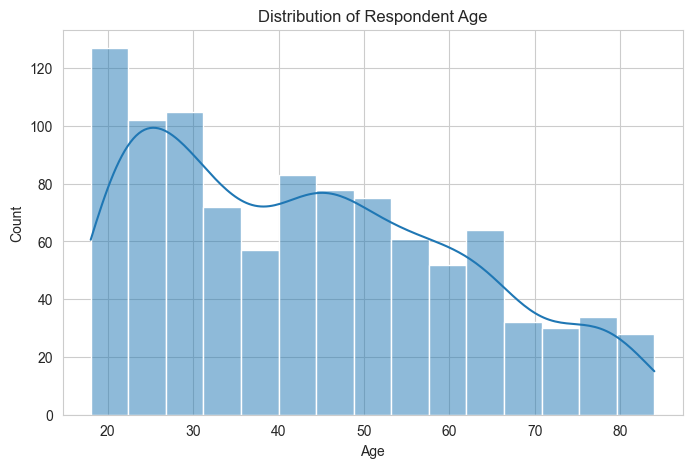

In [42]:
# Age distribution

plt.figure(figsize=(8,5))

sns.histplot(
    nv_data["age"],
    bins=15,
    kde=True
)

plt.title("Distribution of Respondent Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## Univariate EDA: Selected Categorical Distributions

For the categorical distribution analysis, I focus on variables most directly tied to the memo questions: perceived seriousness of housing costs, support for building more housing, support for rent increase limits, restrictions on corporate buyers, and the main housing priority tradeoff.

housing_cost_seriousness
Very serious          638
Somewhat serious      312
Not too serious        49
Not at all serious      1
Name: count, dtype: int64

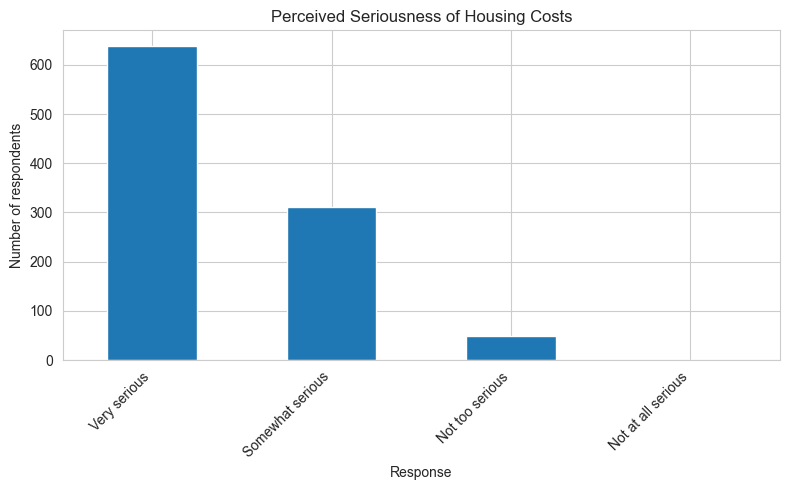

In [43]:
housing_cost_counts = nv_data["housing_cost_seriousness"].value_counts(dropna=False)

display(housing_cost_counts)

housing_cost_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Perceived Seriousness of Housing Costs")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

rent_increase_limit
Strongly support    364
Somewhat support    312
Somewhat oppose     209
Not sure             60
Strongly oppose      55
Name: count, dtype: int64

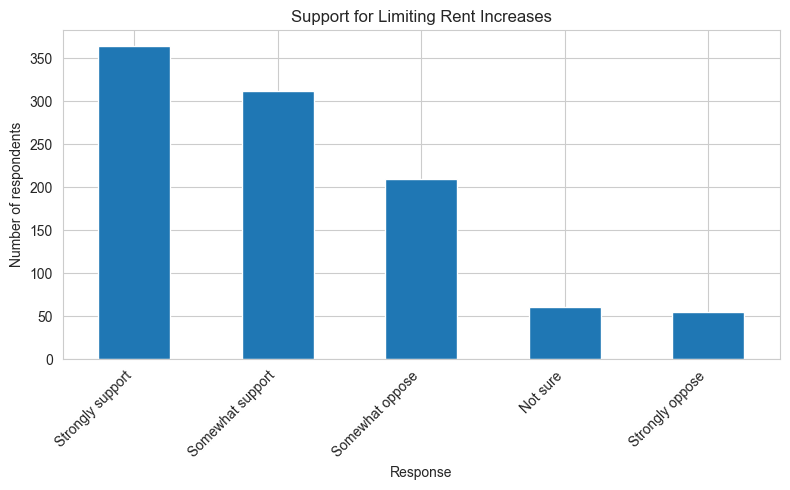

In [47]:
# Rent increase limits
rent_limit_counts = nv_data["rent_increase_limit"].value_counts(dropna=False)

display(rent_limit_counts)

rent_limit_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Support for Limiting Rent Increases")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

allow_more_housing
Somewhat support    313
Strongly support    268
Somewhat oppose     244
Strongly oppose      98
Not sure             77
Name: count, dtype: int64

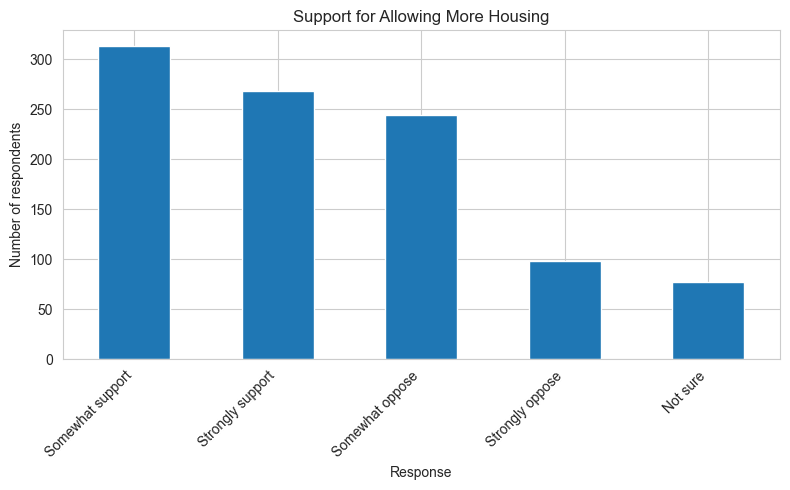

In [44]:
# Allow more housing
more_housing_counts = nv_data["allow_more_housing"].value_counts(dropna=False)

display(more_housing_counts)

more_housing_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Support for Allowing More Housing")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

corporate_buyer_restrictions
Strongly support    463
Somewhat support    321
Somewhat oppose     148
Not sure             53
Strongly oppose      15
Name: count, dtype: int64

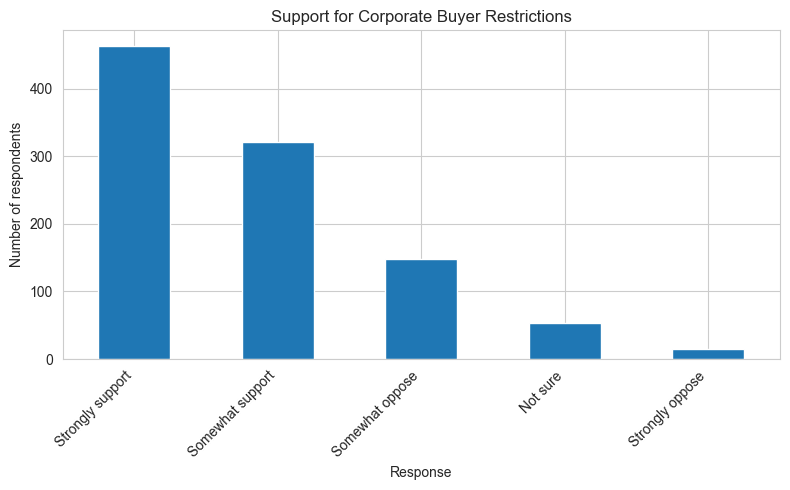

In [45]:
# Corporate buyer restrictions
corporate_counts = nv_data["corporate_buyer_restrictions"].value_counts(dropna=False)

display(corporate_counts)

corporate_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Support for Corporate Buyer Restrictions")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

housing_priority_tradeoff
Build more homes even if neighborhoods change                   447
Protect existing neighborhoods even if fewer homes are built    395
Not sure                                                        158
Name: count, dtype: int64

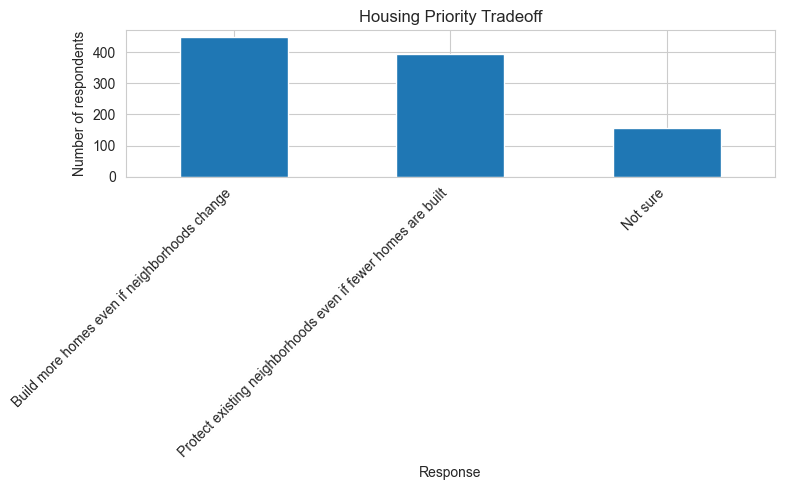

In [46]:
# Housing priority tradeoff
tradeoff_counts = nv_data["housing_priority_tradeoff"].value_counts(dropna=False)

display(tradeoff_counts)

tradeoff_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Housing Priority Tradeoff")
plt.xlabel("Response")
plt.ylabel("Number of respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

These selected distributions give an initial view of public opinion before moving to toplines and crosstabs. The key questions are whether Nevada registered voters see housing affordability as a serious issue, whether they support supply-side housing expansion, whether they prefer regulatory protections such as rent increase limits or corporate buyer restrictions, and how they resolve tradeoffs between affordability and development-related concerns.

## Toplines

In [48]:
def topline_table(data, column):
    counts = data[column].value_counts(dropna=False)
    percents = data[column].value_counts(dropna=False, normalize=True) * 100

    out = pd.DataFrame({
        "Response": counts.index,
        "N": counts.values,
        "Percent": percents.round(0).astype(int).astype(str) + "%"
    })

    return out

In [49]:
topline_vars = [
    "housing_cost_seriousness",
    "allow_more_housing",
    "rent_increase_limit",
    "affordable_housing_tax_credits",
    "development_traffic_concern",
    "corporate_buyer_restrictions",
    "public_land_housing",
    "housing_priority_tradeoff"
]

for var in topline_vars:
    print("\n" + "="*80)
    print(var)
    print("="*80)
    display(topline_table(nv_data, var))


housing_cost_seriousness


,Response,N,Percent
housing_cost_seriousness,,,
Very serious,Very serious,638,64%
Somewhat serious,Somewhat serious,312,31%
Not too serious,Not too serious,49,5%
Not at all serious,Not at all serious,1,0%



allow_more_housing


,Response,N,Percent
allow_more_housing,,,
Somewhat support,Somewhat support,313,31%
Strongly support,Strongly support,268,27%
Somewhat oppose,Somewhat oppose,244,24%
Strongly oppose,Strongly oppose,98,10%
Not sure,Not sure,77,8%



rent_increase_limit


...

,Response,N,Percent
corporate_buyer_restrictions,,,
Strongly support,Strongly support,463,46%
Somewhat support,Somewhat support,321,32%
Somewhat oppose,Somewhat oppose,148,15%
Not sure,Not sure,53,5%
Strongly oppose,Strongly oppose,15,2%



public_land_housing


,Response,N,Percent
public_land_housing,,,
Somewhat support,Somewhat support,308,31%
Somewhat oppose,Somewhat oppose,280,28%
Strongly support,Strongly support,192,19%
Strongly oppose,Strongly oppose,128,13%
Not sure,Not sure,92,9%



housing_priority_tradeoff


,Response,N,Percent
housing_priority_tradeoff,,,
Build more homes even if neighborhoods change,Build more homes even if neighborhoods change,447,45%
Protect existing neighborhoods even if fewer homes are built,Protect existing neighborhoods even if fewer h...,395,40%
Not sure,Not sure,158,16%


## Crosstabs

In [ ]:
# First crosstab: Gender by demographic banners
first_crosstab = pd.concat(
    [
        # All column
        (nv_data["gender"]
         .value_counts(normalize=True)
         .mul(100)
         .round(0)
         .astype(int)
         .astype(str) + "%")
        .rename("All"),

        # Gender banner
        pd.crosstab(
            nv_data["gender"],
            nv_data["gender"],
            normalize="columns"
        ).mul(100).round(0).astype(int).astype(str) + "%",

        # Party banner
        pd.crosstab(
            nv_data["gender"],
            nv_data["party_registration"],
            normalize="columns"
        ).mul(100).round(0).astype(int).astype(str) + "%",

        # Race banner
        pd.crosstab(
            nv_data["gender"],
            nv_data["race_ethnicity"],
            normalize="columns"
        ).mul(100).round(0).astype(int).astype(str) + "%",

        # Education banner
        pd.crosstab(
            nv_data["gender"],
            nv_data["education"],
            normalize="columns"
        ).mul(100).round(0).astype(int).astype(str) + "%"
    ],
    axis=1
)

display(first_crosstab)

,All,Female,Male,Democrat,Independent/Other,Republican,Asian/Pacific Islander,Black,Hispanic/Latino,Other/Mixed,White non-Hispanic,College graduate,High school or less,Postgraduate,Some college/associate
gender,,,,,,,,,,,,,,,
Female,55%,100%,0%,60%,51%,54%,48%,54%,55%,61%,56%,54%,56%,55%,55%
Male,45%,0%,100%,40%,49%,46%,52%,46%,45%,39%,44%,46%,44%,45%,45%


In [60]:
## Counts for crosstabs
# Gender counts
print(nv_data["gender"].value_counts())

# Party counts
print(nv_data["party_registration"].value_counts())

# Race counts
print(nv_data["race_ethnicity"].value_counts())

# Education counts
print(nv_data["education"].value_counts())

gender
Female    551
Male      449
Name: count, dtype: int64
party_registration
Democrat             374
Independent/Other    373
Republican           253
Name: count, dtype: int64
race_ethnicity
White non-Hispanic        485
Hispanic/Latino           269
Black                     108
Other/Mixed                71
Asian/Pacific Islander     67
Name: count, dtype: int64
education
College graduate          350
Some college/associate    284
High school or less       200
Postgraduate              166
Name: count, dtype: int64


In [62]:
# Create polling-style age groups

nv_data["age_group"] = pd.cut(
    nv_data["age"],
    bins=[17, 34, 49, 64, 120],
    labels=["Age 18–34", "Age 35–49", "Age 50–64", "Age 65+"]
)

In [63]:
nv_data["age_group"].value_counts()

age_group
Age 18–34    390
Age 35–49    255
Age 50–64    214
Age 65+      141
Name: count, dtype: int64

In [64]:
housing_age_crosstab = grouped_crosstab(
    nv_data,
    question_var="housing_cost_seriousness",
    banner_vars=["age_group"]
)

display(housing_age_crosstab)

,All,Age 18–34,Age 35–49,Age 50–64,Age 65+
n,n=1000,n=390,n=255,n=214,n=141
Very serious,64%,71%,62%,64%,48%
Somewhat serious,31%,26%,34%,28%,46%
Not too serious,5%,3%,5%,8%,6%
Not at all serious,0%,0%,0%,0%,0%


In [65]:
rent_limit_homeownership = grouped_crosstab(
    nv_data,
    question_var="rent_increase_limit",
    banner_vars=["homeownership"]
)

display(rent_limit_homeownership)

,All,Own,Rent,Other arrangement
n,n=1000,n=490,n=455,n=55
Strongly support,36%,29%,45%,31%
Somewhat support,31%,33%,29%,31%
Somewhat oppose,21%,25%,15%,27%
Not sure,6%,5%,7%,7%
Strongly oppose,6%,8%,3%,4%


In [66]:
tradeoff_age = grouped_crosstab(
    nv_data,
    question_var="housing_priority_tradeoff",
    banner_vars=["age_group"]
)

display(tradeoff_age)

,All,Age 18–34,Age 35–49,Age 50–64,Age 65+
n,n=1000,n=390,n=255,n=214,n=141
Build more homes even if neighborhoods change,45%,47%,41%,45%,45%
Protect existing neighborhoods even if fewer homes are built,40%,39%,42%,38%,38%
Not sure,16%,14%,16%,16%,18%


In [67]:
more_housing_party = grouped_crosstab(
    nv_data,
    question_var="allow_more_housing",
    banner_vars=["party_registration"]
)

display(more_housing_party)

,All,Democrat,Independent/Other,Republican
n,n=1000,n=374,n=373,n=253
Somewhat support,31%,33%,31%,29%
Strongly support,27%,35%,24%,19%
Somewhat oppose,24%,20%,27%,28%
Strongly oppose,10%,5%,12%,15%
Not sure,8%,7%,7%,9%
